# 1 задача


In [ ]:
def total_distance(left_list, right_list):
    # Сортируем оба списка
    left_sorted = sorted(left_list)
    right_sorted = sorted(right_list)

    # Вычисляем сумму абсолютных разностей между соответствующими элементами
    distance = sum(abs(l - r) for l, r in zip(left_sorted, right_sorted))

    return distance

with open('input.txt', 'r') as file:
    lines = file.readlines()
    left_list, right_list = zip(*(map(int, line.split()) for line in lines))

result = total_distance(left_list, right_list)
print(result)

# В первом случае — чтобы разделить входные пары на два списка: левый и правый.
# Во втором случае — чтобы сопоставить элементы из отсортированных списков и посчитать расстояние между ними.

1651298


In [ ]:
# 1 и 2 части
from collections import Counter

def total_distance(left_list, right_list):
    # Сортируем оба списка
    left_sorted = sorted(left_list)
    right_sorted = sorted(right_list)

    # Вычисляем сумму абсолютных разностей между соответствующими элементами
    distance = sum(abs(l - r) for l, r in zip(left_sorted, right_sorted))

    return distance

def similarity_score(left_list, right_list):
    # Подсчитываем количество вхождений чисел в правом списке
    right_counts = Counter(right_list)

    # Вычисляем общий балл сходства
    score = sum(num * right_counts.get(num, 0) for num in left_list)

    return score

# Чтение данных из файла input.txt
with open('input.txt', 'r') as file:
    lines = file.readlines()
    left_list, right_list = zip(*(map(int, line.split()) for line in lines))

# Вычисление расстояния и балла сходства
distance_result = total_distance(left_list, right_list)
similarity_result = similarity_score(left_list, right_list)

print("Total Distance:", distance_result)
print("Similarity Score:", similarity_result)

# 2. дубликаты из слева каждый раз учитываются отдельно

Total Distance: 1651298
Similarity Score: 21306195


# 2 задача


1 часть

In [ ]:
def is_safe_report(report):
    increasing = all(x < y for x, y in zip(report, report[1:]))
    decreasing = all(x > y for x, y in zip(report, report[1:]))
    valid_differences = all(1 <= abs(x - y) <= 3 for x, y in zip(report, report[1:]))
    return (increasing or decreasing) and valid_differences

with open('input.txt', 'r') as file:
    reports = [list(map(int, line.split())) for line in file]

safe_reports_count = sum(1 for report in reports if is_safe_report(report))

print("Safe Reports Count:", safe_reports_count)

Safe Reports Count: 299


2 часть

In [ ]:
# 2 часть
def is_safe_report(report):
    # Проверяем, строго ли возрастающая или убывающая последовательность
    increasing = all(x < y for x, y in zip(report, report[1:]))
    decreasing = all(x > y for x, y in zip(report, report[1:]))

    # Проверяем разницу между соседними элементами
    valid_differences = all(1 <= abs(x - y) <= 3 for x, y in zip(report, report[1:]))

    return (increasing or decreasing) and valid_differences

def can_be_safe_with_removal(report):
    # Пробуем удалить каждый элемент по очереди и проверяем, становится ли отчет безопасным
    for i in range(len(report)):
        modified_report = report[:i] + report[i+1:]
        if is_safe_report(modified_report):
            return True
    return False

with open('input.txt', 'r') as file:
    reports = [list(map(int, line.split())) for line in file]

# Подсчет количества безопасных отчетов с учетом Problem Dampener
safe_reports_count = sum(1 for report in reports if is_safe_report(report) or can_be_safe_with_removal(report))

print("Safe Reports Count (with Problem Dampener):", safe_reports_count)

Safe Reports Count (with Problem Dampener): 364


# 3 задача

1 часть

In [ ]:
# 1 часть
import re

def extract_and_multiply(expressions):
    pattern = r"mul\((\d+),(\d+)\)"
    matches = re.findall(pattern, expressions)
    return sum(int(x) * int(y) for x, y in matches)

with open('input.txt', 'r') as file:
    corrupted_memory = file.read()

result = extract_and_multiply(corrupted_memory)

print("Total multiplication sum:", result)

Total multiplication sum: 170807108


2 часть

In [ ]:
# 2 часть
import re

with open("input.txt", "r") as file:
    corrupted_string = file.read()

# Регулярное выражение для поиска инструкций mul(X,Y)
mul_pattern = r"mul\((\d+),(\d+)\)"
# Регулярное выражение для поиска управляющих команд do() и don't()
control_pattern = r"(do\(\)|don't\(\))"

# Разбираем входную строку по порядку
tokens = re.findall(f"{control_pattern}|{mul_pattern}", corrupted_string)

enabled = True  # По умолчанию инструкции mul выполняются
total_sum = 0

for token in tokens:
    if token[0] == "do()":
        enabled = True
    elif token[0] == "don't()":
        enabled = False
    elif enabled and token[1] and token[2]:  # Это найденная mul(X, Y)
        x, y = int(token[1]), int(token[2])
        total_sum += x * y

print("Сумма всех произведений (с учетом do()/don't()):", total_sum)

Сумма всех произведений (с учетом do()/don't()): 74838033


# 4 задача

1 часть

In [ ]:
import numpy as np

def read_input(filename):
    with open(filename, "r") as f:
        return [line.strip() for line in f.readlines()]

def count_word_occurrences(grid, word):
    rows, cols = len(grid), len(grid[0])
    word_len = len(word)
    count = 0

    directions = [
        (1, 0),  # вниз
        (-1, 0), # вверх
        (0, 1),  # вправо
        (0, -1), # влево
        (1, 1),  # вниз-вправо
        (1, -1), # вниз-влево
        (-1, 1), # вверх-вправо
        (-1, -1) # вверх-влево
    ]

    for r in range(rows):
        for c in range(cols):
            for dr, dc in directions:
                if all(0 <= r + i * dr < rows and 0 <= c + i * dc < cols and grid[r + i * dr][c + i * dc] == word[i] for i in range(word_len)):
                    count += 1
    return count

grid = read_input("input.txt")
word = "XMAS"
result = count_word_occurrences(grid, word)
print(f"Total occurrences of '{word}': {result}")

Total occurrences of 'XMAS': 2591


2 часть

In [ ]:
# 2 часть
def read_input(filename):
    with open(filename, 'r') as file:
        return [line.strip() for line in file.readlines()]

def find_xmas(grid):
    rows, cols = len(grid), len(grid[0])
    count = 0

    def match_xmas(r, c):
        """Проверяет, есть ли X-MAS в 4 возможных формах начиная с (r, c)."""
        if r + 2 >= rows or c + 2 >= cols:
            return False

        # Форма 1: "M M" сверху, "S S" снизу
        if (grid[r][c] == 'M' and grid[r][c + 2] == 'M' and
                grid[r + 1][c + 1] == 'A' and
                grid[r + 2][c] == 'S' and grid[r + 2][c + 2] == 'S'):
            return True

        # Форма 2: "S S" сверху, "M M" снизу
        if (grid[r][c] == 'S' and grid[r][c + 2] == 'S' and
                grid[r + 1][c + 1] == 'A' and
                grid[r + 2][c] == 'M' and grid[r + 2][c + 2] == 'M'):
            return True

        # Форма 3: "M S" сверху, "M S" снизу
        if (grid[r][c] == 'M' and grid[r][c + 2] == 'S' and
                grid[r + 1][c + 1] == 'A' and
                grid[r + 2][c] == 'M' and grid[r + 2][c + 2] == 'S'):
            return True

        # Форма 4: "S M" сверху, "S M" снизу
        if (grid[r][c] == 'S' and grid[r][c + 2] == 'M' and
                grid[r + 1][c + 1] == 'A' and
                grid[r + 2][c] == 'S' and grid[r + 2][c + 2] == 'M'):
            return True

        return False

    # Перебираем каждую возможную точку старта X-MAS
    for r in range(rows - 2):
        for c in range(cols - 2):
            if match_xmas(r, c):
                count += 1
    return count

grid = read_input('input.txt')
result = find_xmas(grid)
print(f"Number of X-MAS patterns: {result}")

Number of X-MAS patterns: 1880


# 5 задача

1 часть

In [ ]:
def read_input(filename):
    with open(filename, 'r') as file:
        sections = file.read().strip().split('\n\n')

    ordering_rules = [tuple(map(int, line.split('|'))) for line in sections[0].split('\n')]
    updates = [list(map(int, line.split(','))) for line in sections[1].split('\n')]

    return ordering_rules, updates

def is_update_valid(ordering_rules, update):
    index_map = {page: i for i, page in enumerate(update)}

    for before, after in ordering_rules:
        if before in index_map and after in index_map:
            if index_map[before] > index_map[after]:
                return False

    return True

def find_middle_page(update):
    return update[len(update) // 2]

ordering_rules, updates = read_input('input.txt')
valid_updates = [update for update in updates if is_update_valid(ordering_rules, update)]
middle_sum = sum(find_middle_page(update) for update in valid_updates)

print(f"Sum of middle pages in valid updates: {middle_sum}")

Sum of middle pages in valid updates: 5991


2 часть

In [ ]:
from collections import defaultdict, deque

def read_input(filename):
    with open(filename, 'r') as file:
        sections = file.read().strip().split('\n\n')

    ordering_rules = [tuple(map(int, line.split('|'))) for line in sections[0].split('\n')]
    updates = [list(map(int, line.split(','))) for line in sections[1].split('\n')]

    return ordering_rules, updates

def is_update_valid(ordering_rules, update):
    index_map = {page: i for i, page in enumerate(update)}

    for before, after in ordering_rules:
        if before in index_map and after in index_map:
            if index_map[before] > index_map[after]:
                return False
    return True

def find_middle_page(update):
    return update[len(update) // 2]

def topological_sort(update, ordering_rules):
    """Исправляем порядок страниц согласно правилам."""
    graph = defaultdict(set)
    in_degree = {page: 0 for page in update}

    for before, after in ordering_rules:
        if before in in_degree and after in in_degree:
            if after not in graph[before]:  # исключаем дубликаты
                graph[before].add(after)
                in_degree[after] += 1

    queue = deque([page for page in update if in_degree[page] == 0])
    sorted_pages = []

    # алгоритм Кана
    while queue:
        page = queue.popleft()
        sorted_pages.append(page)
        for neighbor in graph[page]:
            in_degree[neighbor] -= 1
            if in_degree[neighbor] == 0:
                queue.append(neighbor)

    # если в результате не все страницы — значит был цикл, вернём оригинальный список
    return sorted_pages if len(sorted_pages) == len(update) else update

ordering_rules, updates = read_input('input.txt')

# Берём только некорректные обновления
invalid_updates = [update for update in updates if not is_update_valid(ordering_rules, update)]
# Фиксим их топологической сортировкой
fixed_updates = [topological_sort(update, ordering_rules) for update in invalid_updates]
middle_sum = sum(find_middle_page(update) for update in fixed_updates)
print(f"Sum of middle pages after fixing invalid updates: {middle_sum}")

Sum of middle pages after fixing invalid updates: 5479


# 6 задача

1 часть

In [ ]:
def load_map(filename):
    with open(filename, "r") as f:
        return [list(line.strip()) for line in f.readlines()]

def find_guard(grid):
    direction_order = ['^', '>', 'v', '<']
    for r, row in enumerate(grid):
        for c, cell in enumerate(row):
            if cell in direction_order:
                return (r, c, direction_order.index(cell))
    return None

def simulate_patrol(grid):
    rows, cols = len(grid), len(grid[0])
    visited = set()
    direction_cycle = [(-1, 0), (0, 1), (1, 0), (0, -1)]  # Up, Right, Down, Left

    r, c, dir_index = find_guard(grid)
    visited.add((r, c))
    turns = 0  # Количество поворотов без движения

    while True:
        dr, dc = direction_cycle[dir_index]
        nr, nc = r + dr, c + dc

        # Проверка выхода за границы перед перемещением
        if not (0 <= nr < rows and 0 <= nc < cols):
            break  # Охранник вышел за карту

        if grid[nr][nc] != '#':
            r, c = nr, nc  # Двигайтесь вперед
            visited.add((r, c))
            turns = 0  # Сброс счетчика поворотов
        else:
            dir_index = (dir_index + 1) % 4  # Повернуть вправо
            turns += 1

        if turns >= 4:  # Если 4 раза подряд поворачивался и не двигался, то зациклился
            break

    return len(visited)

grid = load_map("input.txt")
result = simulate_patrol(grid)
print(result)

4903


2 часть

In [ ]:
# 2 часть
def load_map(filename):
    with open(filename, "r") as f:
        return [list(line.strip()) for line in f.readlines()]

def find_guard(grid):
    direction_order = ['^', '>', 'v', '<']
    for r, row in enumerate(grid):
        for c, cell in enumerate(row):
            if cell in direction_order:
                return (r, c, direction_order.index(cell))
    return None

def simulate_patrol(grid): # Находим маршрут охранника
    rows, cols = len(grid), len(grid[0])
    visited = set()
    direction_cycle = [(-1, 0), (0, 1), (1, 0), (0, -1)]  # Up, Right, Down, Left

    r, c, dir_index = find_guard(grid)
    visited.add((r, c))
    turns = 0

    while True:
        dr, dc = direction_cycle[dir_index]
        nr, nc = r + dr, c + dc

        if not (0 <= nr < rows and 0 <= nc < cols):
            break

        if grid[nr][nc] != '#':
            r, c = nr, nc
            visited.add((r, c))
            turns = 0
        else:
            dir_index = (dir_index + 1) % 4
            turns += 1

        if turns >= 4:
            break

    return visited

def is_guard_stuck(grid, obstacle_r, obstacle_c): # Проверяем, застрянет ли охранник
    new_grid = [row[:] for row in grid]     # Создаём копию карты
    new_grid[obstacle_r][obstacle_c] = '#'  # Добавляем препятствие

    rows, cols = len(new_grid), len(new_grid[0])
    direction_cycle = [(-1, 0), (0, 1), (1, 0), (0, -1)]

    r, c, dir_index = find_guard(new_grid) # Получаем стартовую позицию охранника
    visited = set()
    state_history = set()

    while True:
        if (r, c, dir_index) in state_history:
            return True
        state_history.add((r, c, dir_index))

        dr, dc = direction_cycle[dir_index]
        nr, nc = r + dr, c + dc

        if not (0 <= nr < rows and 0 <= nc < cols):
            return False

        if new_grid[nr][nc] != '#':
            r, c = nr, nc
            visited.add((r, c))
        else:
            dir_index = (dir_index + 1) % 4

def count_loop_positions(grid):
    patrol_path = simulate_patrol(grid) # Получаем маршрут охранника
    loop_positions = 0                  # Количество мест, где можно зациклить охранника

    for r, row in enumerate(grid):
        for c, cell in enumerate(row):
            if (r, c) in patrol_path and (r, c) != find_guard(grid)[:2]:
                if is_guard_stuck(grid, r, c):    # Проверяем, застрянет ли охранник
                    loop_positions += 1           # Если да, увеличиваем счётчик

    return loop_positions

grid = load_map("input.txt")
result = count_loop_positions(grid)
print(result)

1911


# 7 задача

1 часть

In [ ]:
from itertools import product

def evaluate_expression(numbers, ops):
    result = numbers[0]
    for i, op in enumerate(ops):
        if op == '+':
            result += numbers[i + 1]
        elif op == '*':
            result *= numbers[i + 1]
    return result

def is_possible(test_value, numbers):
    num_operators = len(numbers) - 1
    for ops in product(['+', '*'], repeat=num_operators):
        if evaluate_expression(numbers, ops) == test_value:
            return True
    return False


total_calibration_result = 0
with open("input.txt", "r") as file:
    for line in file:
        test_value, numbers = line.strip().split(": ")
        test_value = int(test_value)
        numbers = list(map(int, numbers.split()))
        if is_possible(test_value, numbers):
            total_calibration_result += test_value
print(total_calibration_result)

3119088655389


2 часть

In [ ]:
from itertools import product

def evaluate_expression(numbers, ops):
    result = numbers[0]
    for i, op in enumerate(ops):
        if op == '+':
            result += numbers[i + 1]
        elif op == '*':
            result *= numbers[i + 1]
        elif op == '||':
            result = int(str(result) + str(numbers[i + 1]))
    return result

def is_possible(test_value, numbers):
    num_operators = len(numbers) - 1
    for ops in product(['+', '*', '||'], repeat=num_operators):
        if evaluate_expression(numbers, ops) == test_value:
            return True
    return False

total_calibration_result = 0
with open("input.txt", "r") as file:
    for line in file:
        test_value, numbers = line.strip().split(": ")
        test_value = int(test_value)
        numbers = list(map(int, numbers.split()))
        if is_possible(test_value, numbers):
            total_calibration_result += test_value

print(total_calibration_result)

264184041398847


In [ ]:
# 2 часть убыстряем

def is_possible_recursive(index, current_value, numbers, target):
    if index == len(numbers):
        return current_value == target

    next_value = numbers[index]

    # Проверяем все возможные операции
    if (is_possible_recursive(index + 1, current_value + next_value, numbers, target) or
        is_possible_recursive(index + 1, current_value * next_value, numbers, target) or
        is_possible_recursive(index + 1, int(f"{current_value}{next_value}"), numbers, target)):
        return True

    return False

def is_possible(test_value, numbers):
    return is_possible_recursive(1, numbers[0], numbers, test_value)

total_calibration_result = 0
with open("input.txt", "r") as file:
    for line in file:
        test_value, numbers = line.strip().split(": ")
        test_value = int(test_value)
        numbers = list(map(int, numbers.split()))
        if is_possible(test_value, numbers):
            total_calibration_result += test_value

print(total_calibration_result)

264184041398847


# 8 задача

1 часть

In [ ]:
# 1 часть
def read_input(filename):
    with open(filename, "r") as f:
        grid = [line.strip() for line in f.readlines()]
    return grid


def find_antennas(grid):
    antennas = {}
    for y, row in enumerate(grid):
        for x, cell in enumerate(row):
            if cell != ".":
                if cell not in antennas:
                    antennas[cell] = []
                antennas[cell].append((x, y))
    return antennas


def find_antinodes(antennas, width, height):
    antinodes = set()

    # for freq, positions in antennas.items():
    for positions in antennas.values():
        positions.sort()

        for i in range(len(positions)):
            for j in range(i + 1, len(positions)):
                x1, y1 = positions[i]
                x2, y2 = positions[j]

                # Найти возможные точки антиузлов
                dx, dy = x2 - x1, y2 - y1
                x3, y3 = x1 - dx, y1 - dy
                x4, y4 = x2 + dx, y2 + dy

                # Проверяем границы карты
                if 0 <= x3 < width and 0 <= y3 < height:
                    antinodes.add((x3, y3))
                if 0 <= x4 < width and 0 <= y4 < height:
                    antinodes.add((x4, y4))

    return antinodes


grid = read_input("input.txt")
height, width = len(grid), len(grid[0])
antennas = find_antennas(grid)
antinodes = find_antinodes(antennas, width, height)
print(len(antinodes))

278


2 часть

In [ ]:
def read_input(filename):
    with open(filename, "r") as f:
        return [line.strip() for line in f]

def find_antennas(grid):
    antennas = {}
    for y, row in enumerate(grid):
        for x, ch in enumerate(row):
            if ch != ".":
                antennas.setdefault(ch, []).append((x, y))
    return antennas

def find_antinodes(antennas, width, height):
    antinodes = set()

    for freq, positions in antennas.items():
        if len(positions) > 1:
            # Все антенны автоматически становятся антиузлами
            antinodes.update(positions)

            for i in range(len(positions)):
                for j in range(i + 1, len(positions)):
                    x1, y1 = positions[i]
                    x2, y2 = positions[j]

                    dx, dy = x2 - x1, y2 - y1

                    # Двигаемся назад от первой антенны
                    x, y = x1 - dx, y1 - dy
                    while 0 <= x < width and 0 <= y < height:
                        antinodes.add((x, y))
                        x -= dx
                        y -= dy

                    # Двигаемся вперёд от второй антенны
                    x, y = x2 + dx, y2 + dy
                    while 0 <= x < width and 0 <= y < height:
                        antinodes.add((x, y))
                        x += dx
                        y += dy
    return antinodes

grid = read_input("input.txt")
height, width = len(grid), len(grid[0])
antennas = find_antennas(grid)
antinodes = find_antinodes(antennas, width, height)
print(len(antinodes))

1067


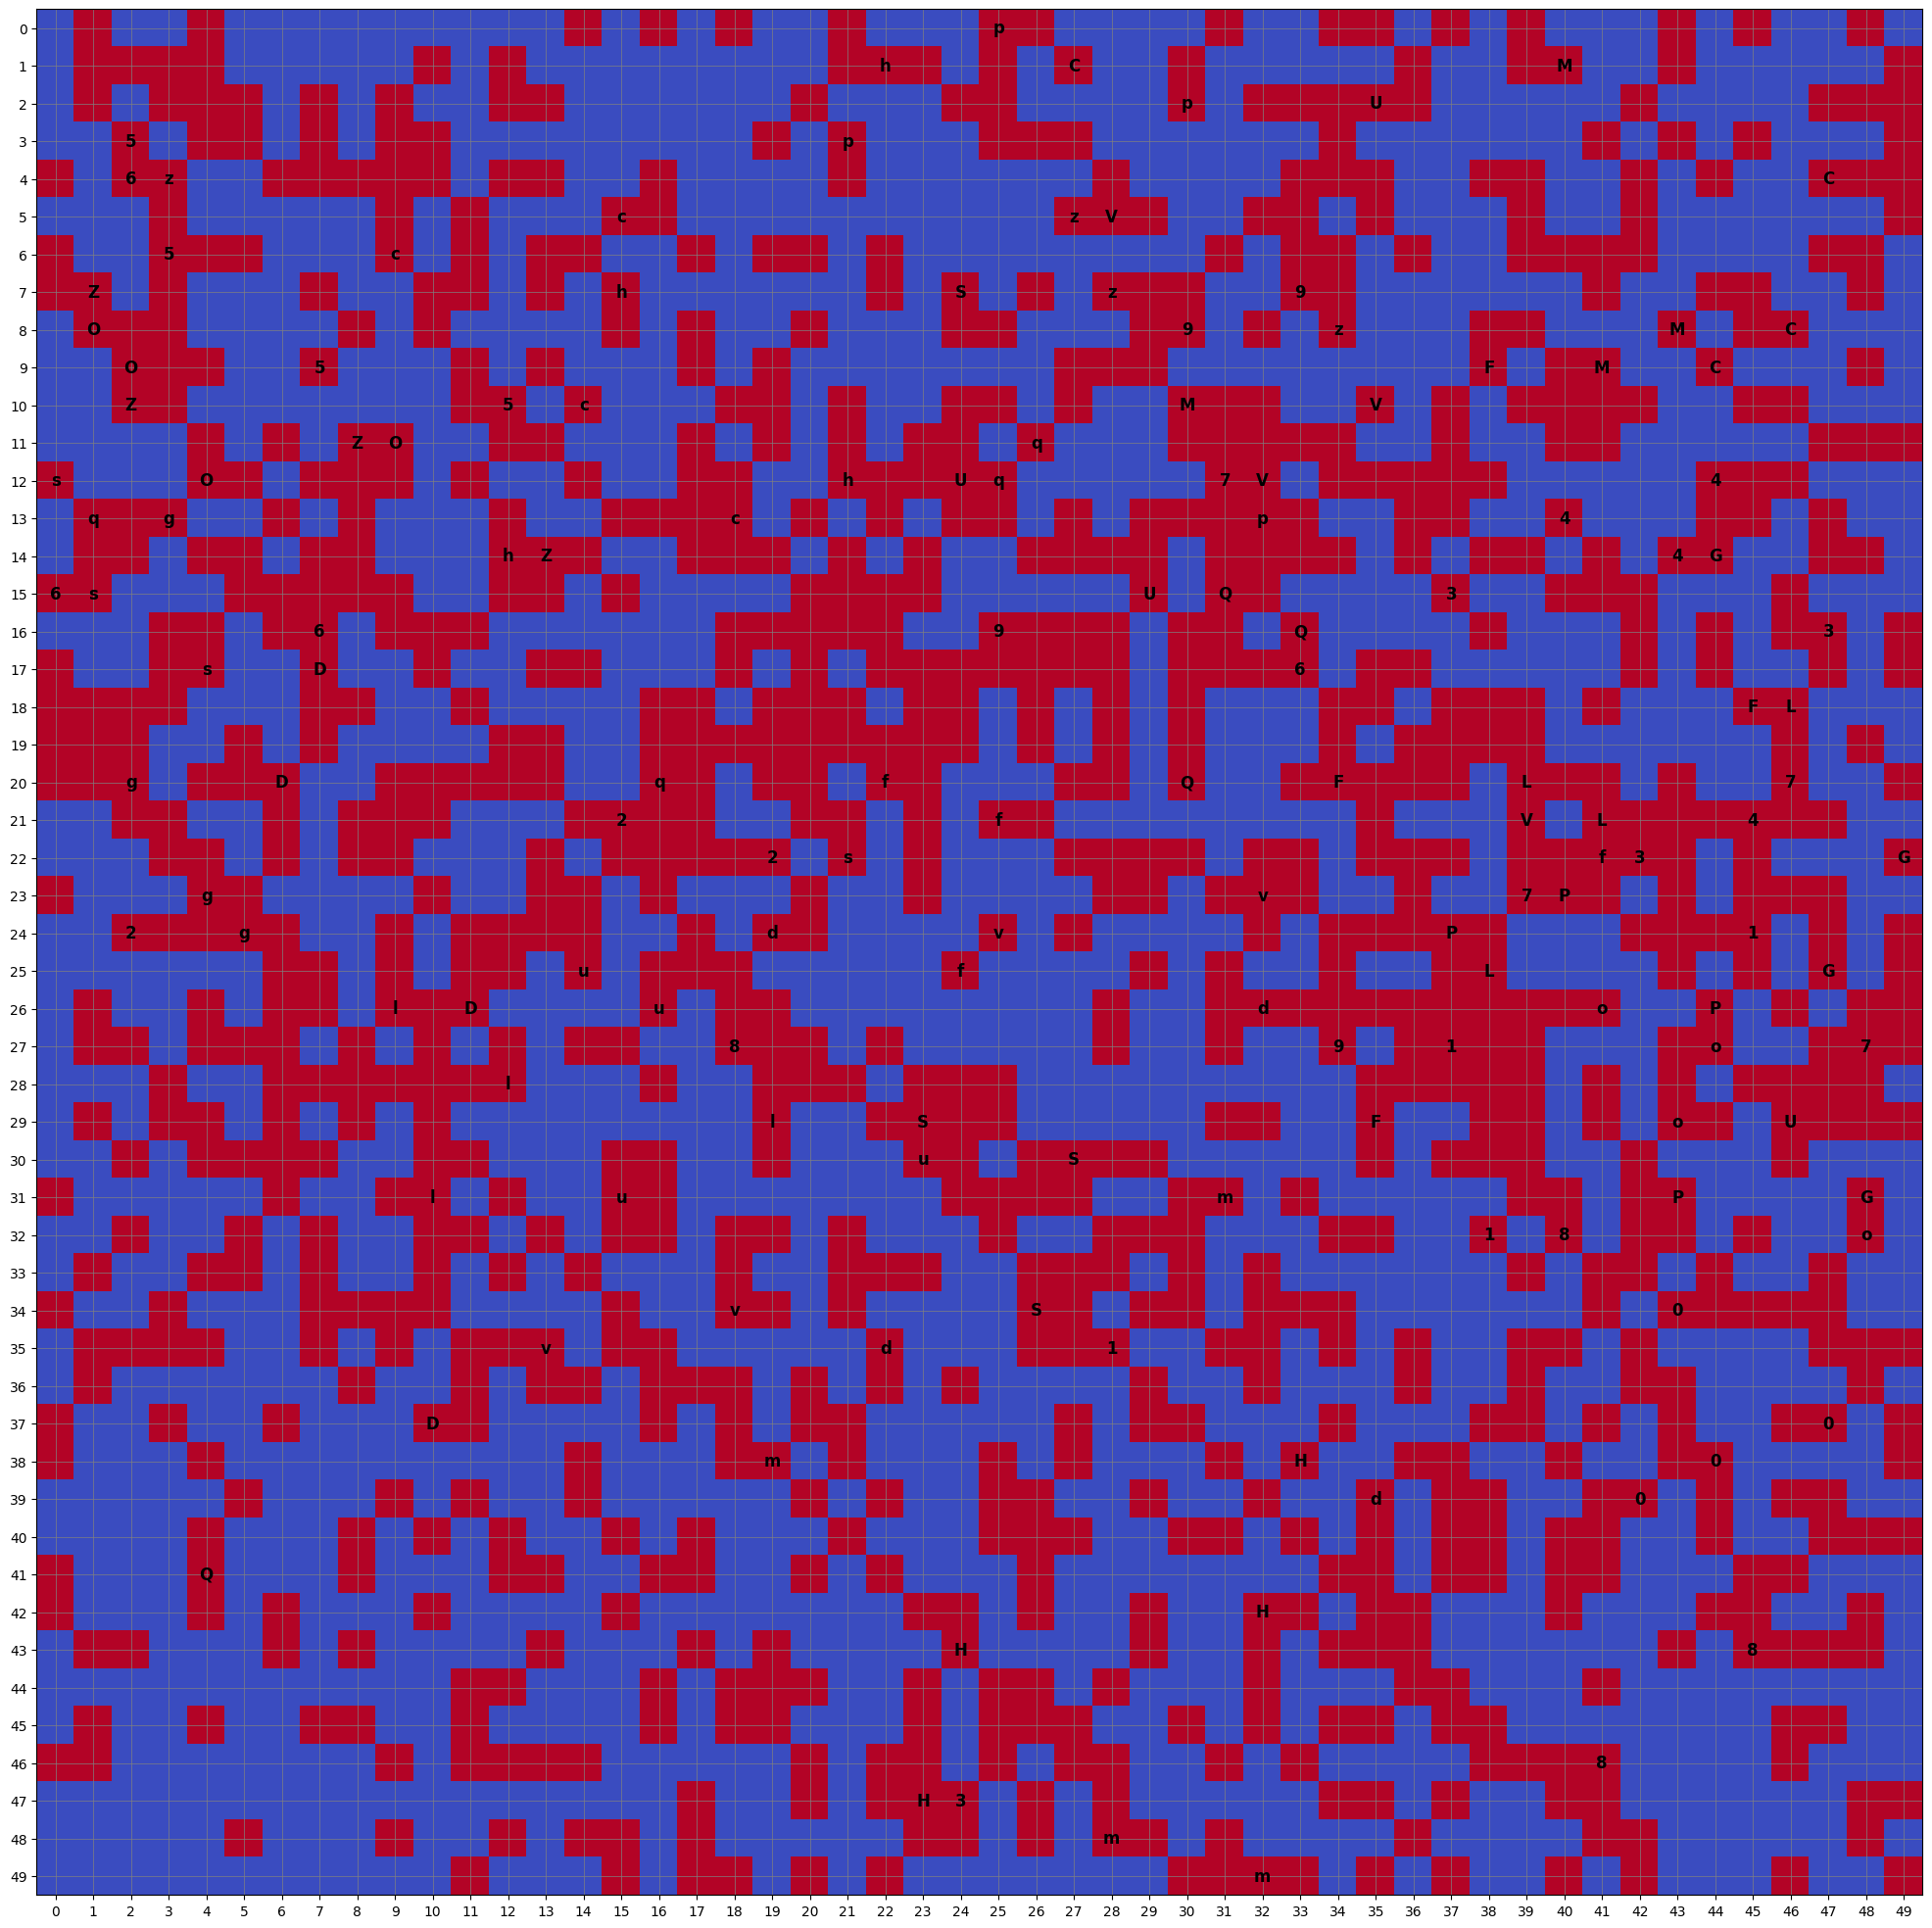

In [ ]:
# визуализация 2-ой задачи
import matplotlib.pyplot as plt
import numpy as np
from math import gcd

def read_input(filename):
    with open(filename, "r") as f:
        return [line.strip() for line in f.readlines()]

def find_antennas(grid):
    """Собираем координаты антенн по частотам."""
    antennas = {}
    for y, row in enumerate(grid):
        for x, cell in enumerate(row):
            if cell != ".":
                if cell not in antennas:
                    antennas[cell] = []
                antennas[cell].append((x, y))
    return antennas

def find_antinodes(antennas, width, height):
    """Находим все антиузлы, проходя через линии всех антенн одной частоты."""
    antinodes = set()

    for freq, positions in antennas.items():
        if len(positions) > 1:
            antinodes.update(positions)  # Добавляем антенны

            for i in range(len(positions)):
                for j in range(i + 1, len(positions)):
                    x1, y1 = positions[i]
                    x2, y2 = positions[j]

                    dx, dy = x2 - x1, y2 - y1
                    step = gcd(abs(dx), abs(dy))
                    dx //= step
                    dy //= step

                    x, y = x1, y1
                    while 0 <= x < width and 0 <= y < height:
                        antinodes.add((x, y))
                        x -= dx
                        y -= dy

                    x, y = x2, y2
                    while 0 <= x < width and 0 <= y < height:
                        antinodes.add((x, y))
                        x += dx
                        y += dy

    return antinodes

def visualize(grid, antennas, antinodes):
    height, width = len(grid), len(grid[0])
    img = np.full((height, width), 0)  # Заполняем нулями (пустые клетки)

    for y in range(height):
        for x in range(width):
            if (x, y) in antinodes:
                img[y, x] = 2  # Антиузел (красный)
            elif any((x, y) in positions for positions in antennas.values()):
                img[y, x] = 1  # Антенна (синий)

    # Визуализация через Matplotlib
    plt.figure(figsize=(width / 2, height / 2))
    plt.imshow(img, cmap="coolwarm", origin="upper")

    for freq, positions in antennas.items():
        for x, y in positions:
            plt.text(x, y, freq, ha='center', va='center', fontsize=12, color='black', fontweight='bold')

    plt.xticks(range(width))
    plt.yticks(range(height))
    plt.grid(visible=True, color="gray", linewidth=0.5)
    plt.show()

# Загружаем карту
grid = read_input("input.txt")
height, width = len(grid), len(grid[0])
antennas = find_antennas(grid)
antinodes = find_antinodes(antennas, width, height)

# Визуализация
visualize(grid, antennas, antinodes)

# 9 задача

1 часть

In [ ]:
def parse_disk_map(disk_map: str):
    """Разбирает строку с картой диска в список блоков."""
    blocks = []
    is_file = True  # Начинаем с файла
    file_id = 0     # ID первого файла
    index = 0
    while index < len(disk_map):
        length = int(disk_map[index])
        if length > 0:
            if is_file:
                blocks.extend([str(file_id)] * length)
                file_id += 1
            else:
                blocks.extend(['.'] * length)  # Заполняем пустоты
        is_file = not is_file
        index += 1
    return blocks

def compact_disk(blocks):
    """Перемещает файлы влево, устраняя пробелы по одному."""
    left = 0  # Указатель на первую пустоту слева
    right = len(blocks) - 1  # Указатель на последнюю цифру справа

    while left < right:
        # Ищем первую пустоту слева
        while left < len(blocks) and blocks[left] != '.':
            left += 1

        # Ищем последний блок файла справа
        while right >= 0 and blocks[right] == '.':
            right -= 1

        # Если нашли пару (пустота слева и файл справа), меняем их местами
        if left < right:
            blocks[left], blocks[right] = blocks[right], blocks[left]
            left += 1
            right -= 1

    return blocks  # Возвращаем список блоков без объединения в строку

def calculate_checksum(blocks):
    """Вычисляет контрольную сумму."""
    return sum(i * int(block) for i, block in enumerate(blocks) if block != '.')

with open("input.txt", "r") as file:
    disk_map = file.read().strip()

blocks = parse_disk_map(disk_map)
print("Исходное состояние:")
print(" ".join(blocks))

blocks = compact_disk(blocks)
print("После сжатия:")
print(" ".join(blocks))

checksum = calculate_checksum(blocks)
print("Контрольная сумма:", checksum)

Исходное состояние:
0 0 0 0 0 0 0 1 1 1 1 . . 2 . . . . . . . . . 3 3 . . . . . . . 4 4 4 4 4 4 4 4 . . . . . . 5 5 5 . . 6 6 . . . . . . . . 7 7 7 7 7 7 7 . . . . . . . . . 8 8 8 8 8 8 8 8 8 9 . . . . . 10 10 10 10 10 10 10 . . . . . . 11 11 11 11 11 11 11 11 11 . . . . . . . . . 12 12 12 . . . . . . . . 13 13 13 13 13 13 13 13 13 . 14 14 14 . . . . . . . 15 15 15 15 15 15 15 . . . . . 16 16 16 16 16 16 16 16 16 17 17 17 17 17 . 18 . . . . . . . 19 19 19 . . . . . . 20 20 20 20 20 20 20 . . . . 21 . . . . . . . 22 22 22 22 22 22 . . . . . . . 23 23 23 . 24 24 24 24 24 . 25 25 25 25 25 25 25 25 25 . . 26 26 26 26 26 26 26 26 26 . . . . . . 27 27 27 27 . . . 28 28 28 . . 29 29 29 29 29 29 29 29 . . . . . . 30 30 30 30 30 30 30 30 31 31 31 31 31 31 31 31 31 . . . . . . . 32 32 32 32 32 32 32 32 32 . 33 33 33 . . . . . . 34 34 34 34 34 34 34 34 35 35 35 . . 36 36 36 36 36 36 36 . . . . . . . . . 37 . 38 38 38 38 39 39 39 39 39 39 39 39 40 40 40 40 . . . . . . . . . 41 41 41 41 . . . . . .

2 часть

In [ ]:
# нужно попробовать ускорить 3 мин
def parse_disk_map(disk_map: str):
    """Разбирает строку с картой диска в список блоков."""
    blocks = []
    is_file = True  # Начинаем с файла
    file_id = 0  # ID первого файла
    index = 0
    file_sizes = {}

    while index < len(disk_map):
        length = int(disk_map[index])
        if length > 0:
            if is_file:
                blocks.extend([str(file_id)] * length)
                file_sizes[file_id] = length
                file_id += 1
            else:
                blocks.extend(['.'] * length)  # Заполняем пустоты
        is_file = not is_file
        index += 1

    return blocks, file_sizes

def move_files(blocks, file_sizes):
    """Перемещает файлы целиком влево, если есть свободное место."""
    file_positions = {}  # Запоминаем начальные позиции файлов

    # Найдем начальные позиции файлов
    start = 0
    for file_id, size in file_sizes.items():
        while start < len(blocks) and blocks[start] == '.':
            start += 1
        file_positions[file_id] = start
        start += size

    # Файлы сортируем по убыванию ID и пытаемся переместить их влево
    for file_id in sorted(file_sizes.keys(), reverse=True):
        size = file_sizes[file_id]
        current_pos = file_positions[file_id]

        # Ищем самое левое возможное место
        # Скользящее окно
        left_pos = 0
        while left_pos < len(blocks) - size:
            if all(blocks[i] == '.' for i in range(left_pos, left_pos + size)):
                break
            left_pos += 1

        # Если нашли место, перемещаем файл
        if left_pos < current_pos:
            # Очистить старое место
            for i in range(current_pos, current_pos + size):
                blocks[i] = '.'
            # Заполнить новое место
            for i in range(left_pos, left_pos + size):
                blocks[i] = str(file_id)

    return blocks

def calculate_checksum(blocks):
    """Вычисляет контрольную сумму."""
    return sum(i * int(block) for i, block in enumerate(blocks) if block != '.')

with open("input.txt", "r") as file:
    disk_map = file.read().strip()

blocks, file_sizes = parse_disk_map(disk_map)
print("Исходное состояние:")
print(" ".join(blocks))

blocks = move_files(blocks, file_sizes)
print("После сжатия:")
print(" ".join(blocks))

checksum = calculate_checksum(blocks)
print("Контрольная сумма:", checksum)

Исходное состояние:
0 0 0 0 0 . . . . . . . . . 1 1 1 1 1 1 1 . . . . . . 2 2 2 2 2 2 2 2 . . . . 3 3 3 3 3 . . . . 4 4 4 . . . . . 5 5 . . . . . 6 6 6 6 6 6 . . . . . . . 7 7 7 7 7 7 7 7 . . . . . . . . 8 8 8 8 8 8 8 8 8 . . . 9 9 9 9 9 9 9 9 . . . . . 10 10 10 10 . . . . . . . 11 11 11 11 11 . . . . . . . 12 12 12 12 12 . . 13 13 13 13 13 13 13 13 . . . . . . . . . 14 14 14 . . . . 15 15 15 15 15 16 16 16 16 . . . . . . . . . 17 . 18 18 . 19 . . . . . . . . . 20 20 20 20 20 20 . 21 21 . . . . . . 22 22 22 22 22 . 23 23 23 23 . . . . . . . 24 24 24 24 24 24 24 . . . 25 25 25 25 25 25 25 25 25 . . . 26 26 26 26 26 26 . . . . 27 27 27 27 27 27 27 27 27 . . . . 28 28 28 28 . . . . . . . . . 29 29 29 29 29 . . . . . . . . 30 30 30 30 30 30 30 30 . 31 31 31 31 31 31 32 32 32 32 32 32 32 32 32 33 33 33 33 33 . . . . . 34 34 34 34 34 34 34 . . . . . 35 35 35 35 35 35 35 35 35 . . . . 36 36 36 36 36 36 . . . . 37 37 37 37 37 37 . . . . . . 38 38 38 38 38 39 39 39 39 39 39 . . . . . . 40 40 40

# 10 задача

1 часть

In [ ]:
from collections import deque

def read_map(filename):
    """Считывает карту высот из файла."""
    with open(filename, "r") as file:
        return [list(map(int, line.strip())) for line in file]

def find_trailheads(height_map):
    """Находит все точки старта (trailheads), которые имеют высоту 0."""
    trailheads = []
    for r in range(len(height_map)):
        for c in range(len(height_map[0])):
            if height_map[r][c] == 0:
                trailheads.append((r, c))
    return trailheads

def bfs(start, height_map):
    """Выполняет поиск в ширину (BFS) для нахождения всех достижимых позиций с высотой 9."""
    rows, cols = len(height_map), len(height_map[0])
    queue = deque([start])
    visited = set([start])
    count = 0

    while queue:
        # берем из очереди следующую валидную клетку
        r, c = queue.popleft()
        if height_map[r][c] == 9:
            count += 1

        # Добавляем в очередь все валидные соседнии клетки, так и двигаемся
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:  # вверх, вниз, влево, вправо
            nr, nc = r + dr, c + dc
            if (0 <= nr < rows and 0 <= nc < cols and (nr, nc) not in visited
                    and height_map[nr][nc] == height_map[r][c] + 1):
                visited.add((nr, nc))
                queue.append((nr, nc))
    # print(count)
    return count

def calculate_total_score(height_map):
    """Вычисляет сумму всех оценок trailheads."""
    trailheads = find_trailheads(height_map)
    total_score = sum(bfs(th, height_map) for th in trailheads)
    return total_score

height_map = read_map("input.txt")

total_score = calculate_total_score(height_map)

print("Сумма всех trailhead score:", total_score)

2
Сумма всех trailhead score: 2


2 часть

In [ ]:
from collections import deque

def read_map(filename):
    """Считывает карту высот из файла."""
    with open(filename, "r") as file:
        return [list(map(int, line.strip())) for line in file]

def find_trailheads(height_map):
    """Находит все точки старта (trailheads), которые имеют высоту 0."""
    trailheads = []
    for r in range(len(height_map)):
        for c in range(len(height_map[0])):
            if height_map[r][c] == 0:
                trailheads.append((r, c))
    return trailheads

def count_paths(r, c, height_map):
    """Рекурсивно считает количество путей от (r, c) до любой точки с высотой 9."""
    rows, cols = len(height_map), len(height_map[0])
    if height_map[r][c] == 9:
        return 1  # Достигли высоты 9, засчитываем путь

    total_paths = 0
    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:  # вверх, вниз, влево, вправо
        nr, nc = r + dr, c + dc
        if (0 <= nr < rows and 0 <= nc < cols and height_map[nr][nc] == height_map[r][c] + 1):
            total_paths += count_paths(nr, nc, height_map)

    return total_paths

def calculate_total_rating(height_map):
    """Вычисляет сумму всех рейтингов trailheads."""
    trailheads = find_trailheads(height_map)
    total_rating = sum(count_paths(th[0], th[1], tuple(map(tuple, height_map))) for th in trailheads)
    return total_rating

height_map = read_map("input.txt")

total_rating = calculate_total_rating(height_map)

print("Сумма всех trailhead ratings:", total_rating)

Сумма всех trailhead ratings: 875


# 11 задача

1 часть

In [ ]:
def read_input(filename):
    """Считывает список камней из файла."""
    with open(filename, "r") as file:
        return list(map(int, file.readline().strip().split()))

def split_number(n):
    """Разбивает число на две части, если оно содержит четное число цифр."""
    str_n = str(n)
    mid = len(str_n) // 2
    left, right = int(str_n[:mid]), int(str_n[mid:])
    return [left, right]

def blink(stones):
    """Один шаг эволюции камней по заданным правилам."""
    new_stones = []
    for stone in stones:
        if stone == 0:
            new_stones.append(1)
        elif len(str(stone)) % 2 == 0:
            new_stones.extend(split_number(stone))
        else:
            new_stones.append(stone * 2024)
    return new_stones

def simulate(filename, blinks=25):
    """Запускает симуляцию изменения камней в течение заданного количества шагов."""
    stones = read_input(filename)
    for _ in range(blinks):
        stones = blink(stones)
    return len(stones)

result = simulate("input.txt", 25)
print("Количество камней после 25 морганий:", result)

Количество камней после 25 морганий: 186996


In [ ]:
stones = read_input("input.txt")
stones
len(stones)

8

2 часть

In [ ]:
from collections import Counter

def read_input(filename):
    """Считывает список камней из файла."""
    with open(filename, "r") as file:
        return list(map(int, file.readline().strip().split()))

def split_number(n):
    """Разбивает число на две части, если оно содержит четное число цифр."""
    str_n = str(n)
    mid = len(str_n) // 2
    left, right = int(str_n[:mid]), int(str_n[mid:])
    return [left, right]

def blink(stones_counter):
    """Один шаг эволюции камней по заданным правилам."""
    new_counter = Counter()
    for stone, count in stones_counter.items():
        if stone == 0:
            new_counter[1] += count
        elif len(str(stone)) % 2 == 0:
            left, right = split_number(stone)
            new_counter[left] += count
            new_counter[right] += count
        else:
            new_counter[stone * 2024] += count
    return new_counter

def simulate(filename, blinks=75):
    """Запускает симуляцию изменения камней в течение заданного количества шагов."""
    stones = read_input(filename)
    stones_counter = Counter(stones)

    for _ in range(blinks):
        stones_counter = blink(stones_counter)

    return sum(stones_counter.values())

result = simulate("input.txt", 75)
print("Количество камней после 75 морганий:", result)

Количество камней после 75 морганий: 221683913164898


In [ ]:
4//2

2

# 12 задача

1 часть

In [ ]:
from collections import deque

def read_input(filename):
    """Считывает карту сада из файла."""
    with open(filename, "r") as file:
        return [list(line.strip()) for line in file]

def get_neighbors(x, y, rows, cols):
    """Возвращает соседние клетки (по вертикали и горизонтали)."""
    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nx, ny = x + dx, y + dy
        if 0 <= nx < rows and 0 <= ny < cols:
            yield nx, ny

def bfs(grid, x, y, visited):
    """Обходит регион, считая его площадь и периметр."""
    rows, cols = len(grid), len(grid[0])
    plant_type = grid[x][y]
    queue = deque([(x, y)])
    visited.add((x, y))
    area = 0
    perimeter = 0

    while queue:
        cx, cy = queue.popleft()
        area += 1
        local_perimeter = 4

        for nx, ny in get_neighbors(cx, cy, rows, cols):
            if grid[nx][ny] == plant_type:
                local_perimeter -= 1
                if (nx, ny) not in visited:
                    visited.add((nx, ny))
                    queue.append((nx, ny))

        perimeter += local_perimeter

    return area * perimeter

def calculate_fencing_cost(filename):
    """Считает общую стоимость ограждения всех регионов."""
    grid = read_input(filename)
    visited = set()
    total_cost = 0

    for x in range(len(grid)):
        for y in range(len(grid[0])):
            if (x, y) not in visited:
                total_cost += bfs(grid, x, y, visited)

    return total_cost

result = calculate_fencing_cost("input.txt")
print("Общая стоимость ограждения:", result)

Общая стоимость ограждения: 1387004


1 & 2 части

In [ ]:
from collections import deque
directions = {
    (1, 0) : 'v',
    (0, 1) : '<',
    (-1, 0) : '^',
    (0, -1) : '>'
}

def part_12_1():
    grid = []

    with open("input.txt") as file:
        grid = [list(line.strip()) for line in file]

    visited = set([])

    def find_plot(x, y):
        current_plot = deque([])
        current_plot.append((x,y))

        plot_size = 0
        plot_perimeter = 0

        while len(current_plot)>0:
            c_x, c_y = current_plot.popleft()

            if(c_x, c_y) in visited:
                continue

            plot_size += 1
            visited.add((c_x, c_y))

            for coordinates in directions.keys():
                n_x, n_y = c_x + coordinates[0], c_y + coordinates[1]

                if n_x < 0 or n_x >= len(grid[0]) or n_y < 0 or n_y >= len(grid):
                    plot_perimeter += 1
                    continue

                if grid[c_y][c_x] != grid[n_y][n_x]:
                    plot_perimeter +=1
                    continue

                if (n_x, n_y) in visited:
                    continue

                current_plot.append((n_x, n_y))

        return plot_size * plot_perimeter

    total_price = 0

    for y in range(len(grid)):
        for x in range(len(grid[0])):
            if grid[y][x] not in visited:
                total_price += find_plot(x, y)

    return total_price

def part_12_2():
    grid = []

    with open("input.txt") as file:
        grid = [list(line.strip()) for line in file]

    visited = set([])

    def find_plot(x, y):
        current_plot = deque([])
        current_plot.append((x,y))

        plot_size = 0
        plot_edges = set([])

        while len(current_plot)>0:
            c_x, c_y = current_plot.popleft()

            if(c_x, c_y) in visited:
                continue

            plot_size += 1
            visited.add((c_x, c_y))

            for coordinates, direction in directions.items():
                n_x, n_y = c_x + coordinates[0], c_y + coordinates[1]

                if n_x < 0 or n_x >= len(grid[0]) or n_y < 0 or n_y >= len(grid):
                    plot_edges.add((n_x, n_y, direction))
                    continue

                if grid[c_y][c_x] != grid[n_y][n_x]:
                    plot_edges.add((n_x, n_y, direction))
                    continue

                if (n_x, n_y) in visited:
                    continue

                current_plot.append((n_x, n_y))
        return plot_size, plot_edges

    def find_edges(plot_edges):
      plot_edges = deque(plot_edges)

      plot_perimeter = 0

      while len(plot_edges) > 0:
          c_x, c_y, c_d = plot_edges.popleft()
          plot_perimeter += 1
          if c_d == '>' or c_d == '<':
              l_x, l_y, l_d = c_x - 1, c_y, c_d

              while (l_x, c_y, l_d) in plot_edges:
                  plot_edges.remove((l_x, l_y, l_d))
                  l_x = l_x - 1

              r_x, r_y, r_d = c_x + 1, c_y, c_d
              while (r_x, r_y, r_d) in plot_edges:
                  plot_edges.remove((r_x, r_y, r_d))
                  r_x = r_x + 1
          elif c_d == '^' or c_d == 'v':
              u_x, u_y, u_d = c_x, c_y - 1, c_d
              while (u_x, u_y, u_d) in plot_edges:
                  plot_edges.remove((u_x, u_y, u_d))
                  u_y = u_y - 1

              d_x, d_y, d_d = c_x, c_y + 1, c_d
              while (d_x, d_y, d_d) in plot_edges:
                  plot_edges.remove((d_x, d_y, d_d))
                  d_y = d_y + 1
      return plot_perimeter

    total_price = 0

    for y in range(len(grid)):
        for x in range(len(grid[0])):
            if grid[y][x] not in visited:
                plot_size, plot_edges = find_plot(x, y)
                plot_perimeter = find_edges(plot_edges)
                total_price += plot_size * plot_perimeter

    return total_price

if __name__ == "__main__":
    print("Day 12, Part 1: " + str(part_12_1()))
    print("Day 12, Part 2: " + str(part_12_2()))

Day 12, Part 1: 1387004
Day 12, Part 2: 844198


# 13 задача

1 часть

In [ ]:
import re
from itertools import product

def parse_input(filename):
    machines = []
    with open(filename, 'r') as file:
        sections = file.read().strip().split('\n\n')
        for section in sections:
            lines = section.split('\n')

            a_match = re.search(r'X\+(\d+), Y\+(\d+)', lines[0])
            b_match = re.search(r'X\+(\d+), Y\+(\d+)', lines[1])
            p_match = re.search(r'X=(\d+), Y=(\d+)', lines[2])

            if not (a_match and b_match and p_match):
                raise ValueError("Invalid input format")

            a_x, a_y = map(int, a_match.groups())
            b_x, b_y = map(int, b_match.groups())
            p_x, p_y = map(int, p_match.groups())

            machines.append(((a_x, a_y), (b_x, b_y), (p_x, p_y)))
    return machines

def find_min_tokens(a_x, a_y, b_x, b_y, p_x, p_y, max_presses=100):
    min_tokens = float('inf')
    best_combination = None

    for a_count, b_count in product(range(max_presses + 1), repeat=2):
        if a_count * a_x + b_count * b_x == p_x and a_count * a_y + b_count * b_y == p_y:
            cost = a_count * 3 + b_count * 1
            if cost < min_tokens:
                min_tokens = cost
                best_combination = (a_count, b_count)

    return min_tokens if best_combination else None

def solve(filename):
    machines = parse_input(filename)
    total_tokens = 0
    prizes_won = 0

    for (a_x, a_y), (b_x, b_y), (p_x, p_y) in machines:
        tokens = find_min_tokens(a_x, a_y, b_x, b_y, p_x, p_y)
        if tokens is not None:
            prizes_won += 1
            total_tokens += tokens

    print(f"Max prizes won: {prizes_won}, Min tokens spent: {total_tokens}")

solve("input.txt")

Max prizes won: 147, Min tokens spent: 29877


2 часть

In [ ]:
#  не решено

# 14 задача

1 часть

In [ ]:
def parse_input(filename):
    robots = []
    with open(filename, 'r') as file:
        for line in file:
            parts = line.strip().split()
            px, py = map(int, parts[0][2:].split(','))
            vx, vy = map(int, parts[1][2:].split(','))
            robots.append(((px, py), (vx, vy)))
    return robots


def simulate(robots, width, height, seconds):
    grid = [[0] * width for _ in range(height)]

    for (px, py), (vx, vy) in robots:
        new_x = (px + vx * seconds) % width
        new_y = (py + vy * seconds) % height
        grid[new_y][new_x] += 1

    return grid


def compute_safety_factor(grid, width, height):
    mid_x, mid_y = width // 2, height // 2
    quadrants = [0, 0, 0, 0]  # Top-left, top-right, bottom-left, bottom-right

    for y in range(height):
        for x in range(width):
            if x == mid_x or y == mid_y:
                continue  # Ignore center lines
            count = grid[y][x]
            if count > 0:
                if x < mid_x and y < mid_y:
                    quadrants[0] += count  # Top-left
                elif x >= mid_x and y < mid_y:
                    quadrants[1] += count  # Top-right
                elif x < mid_x and y >= mid_y:
                    quadrants[2] += count  # Bottom-left
                else:
                    quadrants[3] += count  # Bottom-right

    return quadrants[0] * quadrants[1] * quadrants[2] * quadrants[3]


width, height, seconds = 101, 103, 100
robots = parse_input("input.txt")
grid = simulate(robots, width, height, seconds)
safety_factor = compute_safety_factor(grid, width, height)
print(safety_factor)

222062148


2 часть

In [ ]:
# не решено

# 15 задача

1 часть

In [ ]:
directions = {
    '^': (0, -1),
    'v': (0, 1),
    '<': (-1, 0),
    '>': (1, 0)
}

def part1():
  grid = []
  instructions = ""

  with open("input.txt") as file:
    lines = file.readlines()

    for line in lines:
      if '#' in line:
          grid.append(list(line.strip('\n')))
      else:
          if line[0] in directions:
            instructions += line.strip('\n')

  s_x, s_y = 0, 0

  for y in range(len(grid)):
    for x in range(len(grid[y])):
      if grid[y][x] == '@':
        s_x, s_y = x, y
        break
    if grid[y][x] == '@':
      break

  for instruction in instructions:
    can_move = False

    c_d = directions[instruction]
    c_x, c_y = s_x + c_d[0], s_y + c_d[1]

    while not can_move:
      if grid[c_y][c_x] == '#':
        break
      if grid[c_y][c_x] == '.':
        can_move = True
        break
      c_x, c_y = c_x + c_d[0], c_y + c_d[1]

    if can_move:
      grid[s_y][s_x] = '.'
      if s_x + c_d[0] != c_x or s_y + c_d[1] != c_y:
        grid[c_y][c_x] = 'O'

      s_x, s_y = s_x + c_d[0], s_y + c_d[1]

      grid[s_y][s_x] = '@'

  gps_coords = 0

  for y in range(len(grid)):
    for x in range(len(grid[0])):
      if grid[y][x] == 'O':
          gps_coords += y*100 + x

  return gps_coords

part1()

1421727

2 часть

In [ ]:
# Определяем направления
directions = {
    '^': (0, -1),
    'v': (0, 1),
    '<': (-1, 0),
    '>': (1, 0)
}
# Расширяем карту
expand = {
    '.' : ['.', '.'],
    '#' : ['#', '#'],
    '@' : ['@', '.'],
    'O' : ['[', ']']
}

def part2():
    grid = []
    instructions = ""

    with open("input.txt") as file:
      lines = file.readlines()

      for line in lines:
        if '#' in line:
            current = []
            for char in line.strip('\n'):
              current.extend(expand[char]) # Расширяем карту
            grid.append(current)
        else:
            if line[0] in directions:
              instructions += line.strip('\n')

    s_x, s_y = 0, 0

    for y in range(len(grid)):
      for x in range(len(grid[y])):
        if grid[y][x] == '@':
          s_x, s_y = x, y
          break
      if grid[y][x] == '@':
        break

    def can_move(c_x, c_y, direction, positions):
        n_x, n_y = c_x + direction[0], c_y + direction[1]

        if n_x < 0 or n_y < 0 or n_x >= len(grid[0]) or n_y >= len(grid):
          return False

        if grid[n_y][n_x] == '#':
          return False

        if (n_x, n_y) in positions:
          return positions[(n_x, n_y)]

        if grid[n_y][n_x] == '.':
          return True

        positions[(n_x, n_y)] = False # Ставим False по умолчанию, если не знаем ещё, что это за клетка

        if grid[n_y][n_x] == '[':
          positions[(n_x, n_y)] = True
          positions[(n_x + 1, n_y)] = True
          return can_move(n_x, n_y, direction, positions) and can_move(n_x + 1, n_y, direction, positions)

        if grid[n_y][n_x] == ']':
          positions[(n_x, n_y)] = True
          positions[(n_x - 1, n_y)] = True
          return can_move(n_x, n_y, direction, positions) and can_move(n_x - 1, n_y, direction, positions)

        return can_move(n_x, n_y, direction, positions)

    def update_grid(positions, grid, direction):
        updated_grid = [row[:] for row in grid]  # Глубокая копия списка

        # Определяем порядок сортировки для корректного обновления
        if direction == directions['<']:
            positions = sorted(positions, key=lambda x: (x[1], x[0]))
        elif direction == directions['^']:
            positions = sorted(positions, key=lambda x: (x[0], x[1]))
        elif direction == directions['>']:
            positions = sorted(positions, key=lambda x: (x[1], x[0]), reverse=True)
        elif direction == directions['v']:
            positions = sorted(positions, key=lambda x: (x[0], x[1]), reverse=True)

        for position in positions:
            x, y = position
            new_x, new_y = x + direction[0], y + direction[1]

            # Проверяем, не выходит ли за границы
            if 0 <= new_x < len(grid[0]) and 0 <= new_y < len(grid):
                updated_grid[y][x] = '.'
                updated_grid[new_y][new_x] = grid[y][x]

        return updated_grid


    for instruction in instructions:
        direction = directions[instruction]
        positions = {}
        positions[(s_x, s_y)] = True
        if can_move(s_x, s_y,direction, positions):
            grid = update_grid(positions, grid, direction)
            s_x, s_y = s_x + direction[0], s_y + direction[1]

    gps_coords = 0

    for y in range(len(grid)):
      for x in range(len(grid[0])):
        if grid[y][x] == '[':
            gps_coords += y*100 + x

    return gps_coords

part2()

1463160

# 16 задача

1 часть

In [ ]:
import heapq

def parse_maze(maze_str):
    maze = maze_str.strip().split("\n")
    start, end = None, None

    for y, row in enumerate(maze):
        for x, cell in enumerate(row):
            if cell == 'S':
                start = (x, y)
            elif cell == 'E':
                end = (x, y)

    return maze, start, end

directions = [(1, 0), (0, 1), (-1, 0), (0, -1)]  # Right, Down, Left, Up

def solve_maze(maze_str):
    maze, start, end = parse_maze(maze_str)

    pq = [(0, start[0], start[1], 0)]  # (cost, x, y, direction)
    visited = set()

    while pq:
        cost, x, y, dir_idx = heapq.heappop(pq)
      # то есть мы можем идти по одному пути и пока он дешевый мы идем по нему,
      #  если он становится дороже мы переключаемся на другие пути из pq
      #  извлекаем heapq.heappop(pq)
      #  если не сделать для этого пути heapq.heappush он не продолжится !!!
        if (x, y, dir_idx) in visited:
            continue
        visited.add((x, y, dir_idx))

        if (x, y) == end:
            return cost

        dx, dy = directions[dir_idx]
        nx, ny = x + dx, y + dy
        if 0 <= ny < len(maze) and 0 <= nx < len(maze[0]) and maze[ny][nx] != '#':
            heapq.heappush(pq, (cost + 1, nx, ny, dir_idx))

        left_idx = (dir_idx - 1) % 4
        heapq.heappush(pq, (cost + 1000, x, y, left_idx))

        right_idx = (dir_idx + 1) % 4
        heapq.heappush(pq, (cost + 1000, x, y, right_idx))

    return -1

with open("input.txt", "r") as file:
    maze_input = file.read()

print(solve_maze(maze_input))

11048


2 часть

In [ ]:
import heapq

def parse_maze(maze_str):
    print("Maze input:")
    print(maze_str)
    maze = maze_str.strip().split("\n")
    start, end = None, None

    for y, row in enumerate(maze):
        for x, cell in enumerate(row):
            if cell == 'S':
                start = (x, y)
            elif cell == 'E':
                end = (x, y)

    if start is None or end is None:
        raise ValueError("Maze must contain both 'S' (start) and 'E' (end) tiles.")

    return maze, start, end

directions = [(1, 0), (0, 1), (-1, 0), (0, -1)]  # Right, Down, Left, Up

def find_best_path(maze_str):
    maze, start, end = parse_maze(maze_str)
    pq = [(0, start[0], start[1], 0, frozenset())]  # (cost, x, y, direction, path_set)
    visited = {}
    best_paths = []
    min_cost = float('inf')

    while pq:
        cost, x, y, dir_idx, path = heapq.heappop(pq)

        if (x, y, dir_idx) in visited and visited[(x, y, dir_idx)] <= cost:
            continue
        visited[(x, y, dir_idx)] = cost # сохраняет стоимость cost для посещённого состояния в словарь visited
        path = path | {(x, y)}          # Добавляем новые точки в путь

        if (x, y) == end:
            if cost < min_cost:
                min_cost = cost
                best_paths = [path]
            elif cost == min_cost:
                best_paths.append(path)
            continue

        dx, dy = directions[dir_idx]
        nx, ny = x + dx, y + dy
        if 0 <= ny < len(maze) and 0 <= nx < len(maze[0]) and maze[ny][nx] != '#':
            heapq.heappush(pq, (cost + 1, nx, ny, dir_idx, path))

        left_idx = (dir_idx - 1) % 4
        if (x, y, left_idx) not in visited:
            heapq.heappush(pq, (cost + 1000, x, y, left_idx, path))

        right_idx = (dir_idx + 1) % 4
        if (x, y, right_idx) not in visited:
            heapq.heappush(pq, (cost + 1000, x, y, right_idx, path))

    best_tiles = set()
    for path in best_paths:
        best_tiles.update(path)

    return len(best_tiles)

with open("input.txt", "r") as file:
    maze_input = file.read().strip()

print(find_best_path(maze_input))

Maze input:
#############################################################################################################################################
#...#.#.........#...#.....#.........#.....#.......#.................#...#.....#.......#.....#.......#.......#...............#.....#........E#
#.#.#.#.#.#.#####.#.#.###.#.#.#####.#.#.#.#.#####.###.#.###########.#.#.#.###.#.#.#####.#.###.###.#.#.#######.#######.#####.#.###.#.#######.#
#.#...#...#.#.....#.#.#.........................#...#.#.....#...#.....#.#...#.#.#.......#.....#...#...#.....#.#...#...#.#...#...#.#.....#.#.#
#.#####.#.#.#.#####.#.#.#.#.###.###.#.#.#.###.#.###.#######.#.#.#########.###.#.###############.#######.###.#.#.#.#.###.#.#####.#.#####.#.#.#
#.......#.#...#...#.#.#.#...#.................#.#.........................#...#.#...#.........#...#.....#...#.#.#.#.....#.#.....#...#.....#.#
#.#.#####.#####.###.#.#.#####.###.#.###.###.###.#########.#.#.###.#.#######.###.#.###.#######.#.#.#.#####.###.###.###.#.#.#.#.#####.###.

In [ ]:
# 2 часть
# 22 минуты
import heapq

def parse_maze(maze_str):
    maze = maze_str.strip().split("\n")
    start, end = None, None

    for y, row in enumerate(maze):
        for x, cell in enumerate(row):
            if cell == 'S':
                start = (x, y)
            elif cell == 'E':
                end = (x, y)

    if start is None or end is None:
        raise ValueError("Maze must contain both 'S' (start) and 'E' (end) tiles.")

    return maze, start, end

DIRECTIONS = [(1, 0), (0, 1), (-1, 0), (0, -1)]  # Right, Down, Left, Up

def find_best_path(maze_str):
    maze, start, end = parse_maze(maze_str)
    pq = [(0, start[0], start[1], 0, frozenset())]  # (cost, x, y, direction, path_set)
    visited = {}
    best_tiles = set()
    min_cost = float('inf')

    while pq:
        cost, x, y, dir_idx, path = heapq.heappop(pq)

        # Если узел уже посещен с меньшей стоимостью, пропускаем
        if (x, y, dir_idx) in visited and visited[(x, y, dir_idx)] < cost:
            continue
        visited[(x, y, dir_idx)] = cost
        path = path | {(x, y)}

        # Если достигли конца
        if (x, y) == end:
            if cost < min_cost:
                min_cost = cost
                best_tiles = set(path)  # Сбрасываем старые пути
            elif cost == min_cost:
                best_tiles.update(path)  # Добавляем новый путь
            continue

        # Двигаемся вперед
        dx, dy = DIRECTIONS[dir_idx]
        nx, ny = x + dx, y + dy
        if 0 <= ny < len(maze) and 0 <= nx < len(maze[0]) and maze[ny][nx] != '#':
            heapq.heappush(pq, (cost + 1, nx, ny, dir_idx, path))

        # Повороты (левая и правая ротация)
        left_idx = (dir_idx - 1) % 4
        right_idx = (dir_idx + 1) % 4
        heapq.heappush(pq, (cost + 1000, x, y, left_idx, path))
        heapq.heappush(pq, (cost + 1000, x, y, right_idx, path))

    return len(best_tiles)

# Читаем входные данные из файла
with open("input.txt", "r") as file:
    maze_input = file.read().strip()

print(find_best_path(maze_input))


494


In [ ]:
# часть 1 и 2 быстро
import networkx as nx

with open("input.txt") as f:
    ls = f.read().strip().split("\n")

fourdir = (1, -1, 1j, -1j)

G = nx.DiGraph()

for i, l in enumerate(ls):
    for j, x in enumerate(l):
        if x == "#":
            continue
        z = i + 1j * j
        if x == "S":
            start = (z, 1j)
        if x == "E":
            end = z
        for dz in fourdir:
            G.add_node((z, dz))

for z, dz in G.nodes:
    if (z + dz, dz) in G.nodes:
        G.add_edge((z, dz), (z + dz, dz), weight=1)
    for rot in -1j, 1j:
        G.add_edge((z, dz), (z, dz * rot), weight=1000)

for dz in fourdir:
    G.add_edge((end, dz), "end", weight=0)

# Part 1
print(nx.shortest_path_length(G, start, "end", weight="weight"))

# Part 2
print( # создание множества (set comprehension)
    len(
        {
            z
            for path in nx.all_shortest_paths(G, start, "end", weight="weight")
            for z, _ in path[:-1]
        }
    )
)

75416
476


# 17 задача

1 часть

In [ ]:
def run_program(registers, program):
    ip = 0       # указатель на текущую инструкцию
                 # Каждые 2 числа — одна инструкция: [opcode, operand]
                 # [2, 4, 1, 1, 7, 5, 4, 0, 0, 3, 1, 6, 5, 5, 3, 0]
    output = []  # Список, куда будут сохраняться результаты инструкции out (opcode 5).
    def get_combo_value(operand):
        if operand < 4:
            return operand
        return registers["ABC"[operand - 4]]

    while ip < len(program):
        opcode, operand = program[ip], program[ip + 1]
        ip += 2

        # Делим A на степень двойки.
        if opcode == 0:  # adv
            denom = 2 ** get_combo_value(operand)
            registers['A'] //= denom

        # Побитовый XOR между B и литеральным числом.
        elif opcode == 1:  # bxl
            registers['B'] ^= operand

        # Обрезаем значение до 3 бит и пишем в B.
        elif opcode == 2:  # bst
            registers['B'] = get_combo_value(operand) % 8

        # Если A не ноль — перепрыгиваем по адресу operand.
        # ip += 2 в этом случае не применяется!
        elif opcode == 3:  # jnz
            if registers['A'] != 0:
                ip = operand

        # Игнорирует operand. Просто делает B = B ^ C.
        elif opcode == 4:  # bxc
            registers['B'] ^= registers['C']

        # Берём значение, мод 8, и добавляем в выход как строку.
        elif opcode == 5:  # out
            output.append(str(get_combo_value(operand) % 8))

        # То же, что adv, но записываем в B.
        elif opcode == 6:  # bdv
            denom = 2 ** get_combo_value(operand)
            registers['B'] = registers['A'] // denom

        # # То же, что adv, но записываем в C.
        elif opcode == 7:  # cdv
            denom = 2 ** get_combo_value(operand)
            registers['C'] = registers['A'] // denom

    return ",".join(output)

with open("input.txt") as f:
    lines = f.read().splitlines()

registers = {}
program = []

for line in lines:
    if line.startswith("Register"):
        parts = line.split(": ")
        registers[parts[0][-1]] = int(parts[1])
    elif line.startswith("Program"):
        program = list(map(int, line.split(": ")[1].split(",")))

result = run_program(registers, program)
print(result)

1,6,3,6,5,6,5,1,7


2 часть

In [ ]:
# нет

# 18 задача

1 часть

In [ ]:
from collections import deque

def read_input(filename):
    with open(filename) as f:
        return [tuple(map(int, line.strip().split(','))) for line in f.readlines()]

# Алгоритм поиска в ширину (BFS) для нахождения кратчайшего пути
def bfs(grid, start, end):
    rows, cols = len(grid), len(grid[0])
    queue = deque([start])
    visited = set([start])
    steps = 0

    # Направления для перемещения (вверх, вниз, влево, вправо)
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while queue:
        for _ in range(len(queue)):
            x, y = queue.popleft()

            # Если достигли цели, возвращаем количество шагов
            if (x, y) == end:
                return steps

            # Пытаемся двигаться в 4 направления
            for dx, dy in directions:
                nx, ny = x + dx, y + dy
                if 0 <= nx < rows and 0 <= ny < cols and (nx, ny) not in visited and grid[nx][ny] != '#':
                    visited.add((nx, ny))
                    queue.append((nx, ny))

        # Увеличиваем количество шагов
        steps += 1

    # Если нет пути, возвращаем -1
    return -1

def simulate_bytes(input_coords, grid_size=71):
    # Инициализация сетки (все клетки изначально безопасны)
    grid = [['.' for _ in range(grid_size)] for _ in range(grid_size)]

    # Поглощение байтов и помечание их как поврежденные
    for i, (x, y) in enumerate(input_coords):
        grid[y][x] = '#'

        # После каждого байта ищем кратчайший путь от (0, 0) до (70, 70)
        if i == 1023:  # Когда мы поместим 1024 байта, запускаем поиск пути
            result = bfs(grid, (0, 0), (grid_size - 1, grid_size - 1))
            return result

    return -1


input_coords = read_input('input.txt')
result = simulate_bytes(input_coords)
print(result)

374


2 часть

In [ ]:
from collections import deque

def read_input(filename):
    with open(filename) as f:
        return [tuple(map(int, line.strip().split(','))) for line in f.readlines()]

def bfs(grid, start, end):
    rows, cols = len(grid), len(grid[0])
    queue = deque([start])
    visited = set([start])
    steps = 0

    # вверх, вниз, влево, вправо
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while queue:
        for _ in range(len(queue)):
            x, y = queue.popleft()

            if (x, y) == end:
                return steps

            for dx, dy in directions:
                nx, ny = x + dx, y + dy
                if 0 <= nx < rows and 0 <= ny < cols and (nx, ny) not in visited and grid[nx][ny] != '#':
                    visited.add((nx, ny))
                    queue.append((nx, ny))
        steps += 1
    return -1

def simulate_bytes(input_coords, grid_size=71):
    grid = [['.' for _ in range(grid_size)] for _ in range(grid_size)]
    for i, (x, y) in enumerate(input_coords):
        grid[y][x] = '#'
        if bfs(grid, (0, 0), (grid_size - 1, grid_size - 1)) == -1:
            return x, y
    return -1

input_coords = read_input('input.txt')
result = simulate_bytes(input_coords)
print(result)

(30, 12)


# 19 задача

1 часть

In [ ]:
def can_create_design(design, towel_patterns):
    n = len(design)
    dp = [False] * (n + 1)
    dp[0] = True  # Пустой дизайн всегда возможен

    for i in range(1, n + 1):
        for towel in towel_patterns:
            towel_len = len(towel)
            # Если дизайн заканчивается на полотенце, и часть дизайна до этого возможна
            if i >= towel_len and dp[i - towel_len] and design[i - towel_len:i] == towel:
                dp[i] = True
                break

    return dp[n]

# Дизайн: "brwrr"
# Доступные полотенца: ["r", "wr", "b", "g", "bwu", "rb", "gb", "br"]

def count_possible_designs(towel_patterns, designs):
    possible_count = 0
    for design in designs:
        if can_create_design(design, towel_patterns):
            possible_count += 1
    return possible_count

def read_input(filename):
    with open(filename) as f:
        lines = f.read().strip().split('\n')

    towel_patterns = lines[0].split(', ')  # Полотенца из первой строки
    designs = lines[2:]                    # Дизайны начинаются с третьей строки
    return towel_patterns, designs


towel_patterns, designs = read_input('input.txt')

result = count_possible_designs(towel_patterns, designs)
print(result)

213


2 часть

In [ ]:
def count_ways_to_create_design(design, towel_patterns):
    n = len(design)
    dp = [0] * (n + 1)
    dp[0] = 1  # Пустой дизайн можно собрать 1 способом (не используя полотенца)

    for i in range(1, n + 1):
        for towel in towel_patterns:
            towel_len = len(towel)
            # Если дизайн заканчивается на полотенце, и часть дизайна до этого можно собрать
            if i >= towel_len and dp[i - towel_len] > 0 and design[i - towel_len:i] == towel:
                dp[i] += dp[i - towel_len]

    return dp[n]

def count_total_ways(towel_patterns, designs):
    total_ways = 0
    for design in designs:
        total_ways += count_ways_to_create_design(design, towel_patterns)
    return total_ways

def read_input(filename):
    with open(filename) as f:
        lines = f.read().strip().split('\n')

    towel_patterns = lines[0].split(', ')  # Полотенца из первой строки
    designs = lines[2:]                    # Дизайны начинаются с третьей строки
    return towel_patterns, designs

towel_patterns, designs = read_input('input.txt')

result = count_total_ways(towel_patterns, designs)
print(result)

1016700771200474
